<a href="https://colab.research.google.com/github/BilalAsifB/MissenseImpact-FYP/blob/main/notebooks/data-preprocessing/Bilal/process_data_1000genome_session_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
reference_fasta = '/content/drive/MyDrive/FYP_DATA/raw_data/reference_fasta/hg38_dna.fa'
input_vcf = '/content/drive/MyDrive/FYP_DATA/raw_data/1000_genomes_project_grch38/chr22.vcf.gz'
output_dir = '/content/drive/MyDrive/FYP_DATA/processed_data/1k'
output_vcf = f'{output_dir}/1k_chr22_normalized.vcf.gz'

In [ ]:
!pip install cyvcf2 --quiet
!apt-get update
!apt-get install -y bcftools tabix

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,385 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,599 kB]
Get:14 http://archive.ubun


1000 GENOMES NORMALIZATION PIPELINE - CHROMOSOME 22

STEP 1: Adding 'chr' prefix to chromosome 22
📝 Renaming: 22 → chr22
⏱️  Renaming chromosome...
✓ Chromosome renamed to chr22
📑 Creating index for 1k_chr22_renamed.vcf.gz...
✓ Index created (34.2 KB)

STEP 2: Normalizing VCF
⏱️  Normalizing VCF (splitting multi-allelic, left-aligning)...

📊 Normalization Stats:
Lines   total/split/realigned/skipped:	1059079/0/0/0


✓ Normalized VCF created successfully!
📑 Creating index for 1k_chr22_normalized.vcf.gz...
✓ Index created (34.2 KB)

STEP 3: Verifying normalization

Scanning up to 10,000 variants...

✓ Verification Results:
   Total variants checked: 10,000
   Chromosomes found: ['chr22']
   Multi-allelic variants: 0
   ✓ All sampled variants are properly split!
   Removed: 1k_chr22_renamed.vcf.gz
   Removed: 1k_chr22_renamed.vcf.gz.tbi

✓ Cleaned up 2 temporary files

✅ CHROMOSOME 22 NORMALIZATION COMPLETE!

📂 Output file:
   /content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr22_no

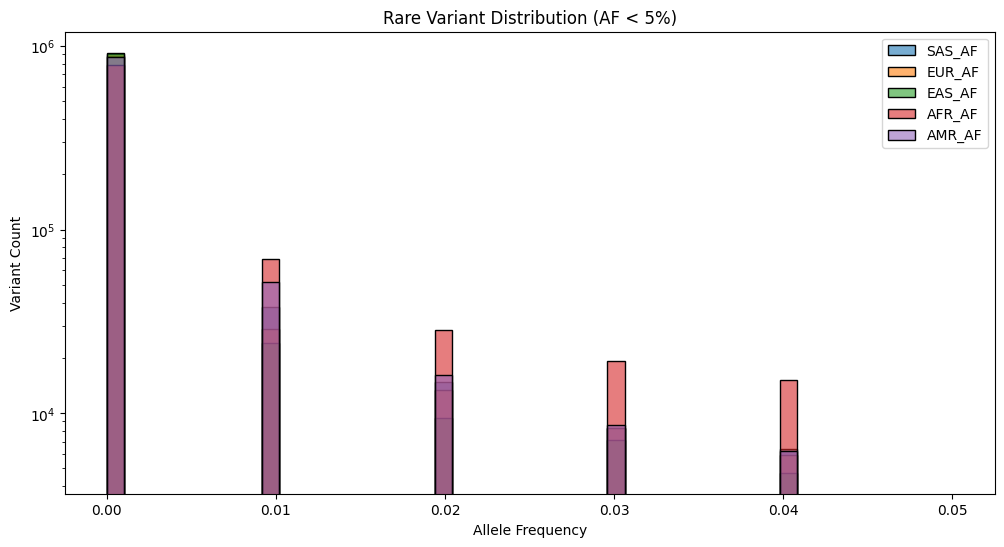

<Figure size 600x500 with 0 Axes>

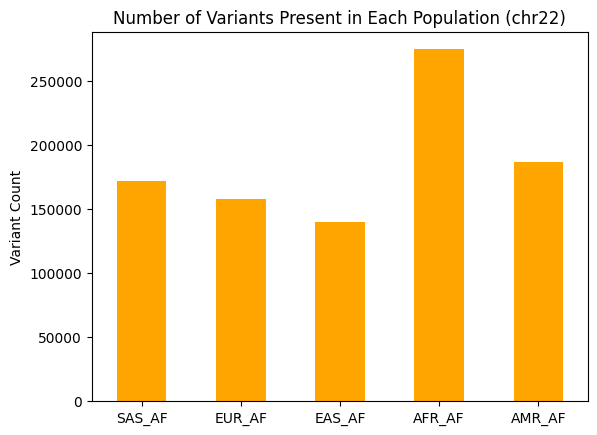

In [ ]:
import subprocess
import os
import pandas as pd
from cyvcf2 import VCF
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# NORMALIZATION FUNCTIONS
# ============================================================

def add_chr_prefix(input_vcf, output_vcf, chrom_number, temp_dir='/tmp'):

    print("\n" + "=" * 70)
    print(f"STEP 1: Adding 'chr' prefix to chromosome {chrom_number}")
    print("=" * 70)

    # Create chromosome rename file
    chr_rename_file = f'{temp_dir}/chr{chrom_number}_rename.txt'
    with open(chr_rename_file, 'w') as f:
        f.write(f"{chrom_number} chr{chrom_number}\n")

    print(f"📝 Renaming: {chrom_number} → chr{chrom_number}")

    rename_cmd = f"""
    bcftools annotate \
        --rename-chrs {chr_rename_file} \
        -O z \
        -o {output_vcf} \
        {input_vcf}
    """

    print("⏱️  Renaming chromosome...")
    result = subprocess.run(
        rename_cmd,
        shell=True,
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print("\n❌ CHROMOSOME RENAMING FAILED!")
        print(result.stderr)
        raise Exception("Chromosome renaming failed")

    print(f"✓ Chromosome renamed to chr{chrom_number}")

    # Cleanup rename file
    if os.path.exists(chr_rename_file):
        os.remove(chr_rename_file)

    return output_vcf


def index_vcf(vcf_file):

    print(f"📑 Creating index for {os.path.basename(vcf_file)}...")

    index_result = subprocess.run(
        f"tabix -f -p vcf {vcf_file}",
        shell=True,
        capture_output=True,
        text=True
    )

    if index_result.returncode != 0:
        print(f"❌ Indexing failed!")
        print(f"Error: {index_result.stderr}")
        raise Exception("Failed to create index")

    # Verify index exists
    if os.path.exists(f"{vcf_file}.tbi"):
        index_size = os.path.getsize(f"{vcf_file}.tbi") / 1024
        print(f"✓ Index created ({index_size:.1f} KB)")
        return True
    else:
        print("❌ Index file not found!")
        raise Exception("Failed to create index")


def normalize_vcf(input_vcf, output_vcf, reference_fasta):


    print("\n" + "=" * 70)
    print("STEP 2: Normalizing VCF")
    print("=" * 70)

    norm_cmd = f"""
    bcftools norm \
        -m- \
        -f {reference_fasta} \
        --check-ref w \
        -O z \
        -o {output_vcf} \
        {input_vcf}
    """

    print("⏱️  Normalizing VCF (splitting multi-allelic, left-aligning)...")
    result = subprocess.run(
        norm_cmd,
        shell=True,
        capture_output=True,
        text=True
    )

    # Print normalization stats
    if result.stderr:
        print("\n📊 Normalization Stats:")
        print(result.stderr)

    if result.returncode != 0:
        print("\n❌ NORMALIZATION FAILED!")
        print(result.stdout)
        print(result.stderr)
        raise Exception("Normalization failed")

    print(f"\n✓ Normalized VCF created successfully!")

    return output_vcf


def verify_normalization(vcf_file, sample_size=10000):

    print("\n" + "=" * 70)
    print("STEP 3: Verifying normalization")
    print("=" * 70)

    vcf = VCF(vcf_file)

    chromosomes_found = set()
    multi_count = 0
    total = 0

    print(f"\nScanning up to {sample_size:,} variants...")

    for variant in vcf:
        chromosomes_found.add(variant.CHROM)
        if len(variant.ALT) > 1:
            multi_count += 1
        total += 1

        if total >= sample_size:
            break

    print(f"\n✓ Verification Results:")
    print(f"   Total variants checked: {total:,}")
    print(f"   Chromosomes found: {sorted(chromosomes_found)}")
    print(f"   Multi-allelic variants: {multi_count}")

    if multi_count == 0:
        print("   ✓ All sampled variants are properly split!")
    else:
        print(f"   ⚠️  Found {multi_count} multi-allelic variants in sample")

    return {
        'total_checked': total,
        'chromosomes': list(chromosomes_found),
        'multi_allelic_count': multi_count
    }


def cleanup_temp_files(file_list):


    cleaned_count = 0
    for temp_file in file_list:
        if os.path.exists(temp_file):
            try:
                os.remove(temp_file)
                cleaned_count += 1
                print(f"   Removed: {os.path.basename(temp_file)}")
            except Exception as e:
                print(f"   Could not remove {os.path.basename(temp_file)}: {e}")

    print(f"\n✓ Cleaned up {cleaned_count} temporary files")

    return cleaned_count


# ============================================================
# MAIN NORMALIZATION PIPELINE
# ============================================================

def normalize_chromosome_pipeline(input_vcf, output_vcf, reference_fasta,
                                  chrom_number, output_dir, temp_dir='/tmp'):


    print("\n" + "=" * 80)
    print(f"1000 GENOMES NORMALIZATION PIPELINE - CHROMOSOME {chrom_number}")
    print("=" * 80)

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(temp_dir, exist_ok=True)

    # Define temporary file paths
    temp_chr_renamed = f'{temp_dir}/1k_chr{chrom_number}_renamed.vcf.gz'

    # Step 1: Add chr prefix
    add_chr_prefix(input_vcf, temp_chr_renamed, chrom_number, temp_dir)

    # Index renamed file
    index_vcf(temp_chr_renamed)

    # Step 2: Normalize
    normalize_vcf(temp_chr_renamed, output_vcf, reference_fasta)

    # Index normalized file
    index_vcf(output_vcf)

    # Step 3: Verify
    verify_normalization(output_vcf)

    # Step 4: Cleanup
    cleanup_temp_files([
        temp_chr_renamed,
        f'{temp_chr_renamed}.tbi'
    ])

    # Final summary
    print("\n" + "=" * 80)
    print(f"✅ CHROMOSOME {chrom_number} NORMALIZATION COMPLETE!")
    print("=" * 80)
    print(f"\n📂 Output file:")
    print(f"   {output_vcf}")
    print(f"\n📂 Index file:")
    print(f"   {output_vcf}.tbi")

    output_size = os.path.getsize(output_vcf) / (1024 * 1024)
    print(f"\n📊 File size: {output_size:.1f} MB")
    print("=" * 80)

    return output_vcf


# ============================================================
# VCF EXTRACTION FUNCTIONS
# ============================================================

def extract_vcf_to_dataframe(vcf_path, chrom_number=None):
    """
    Extract 1000 Genomes VCF to pandas DataFrame

    Args:
        vcf_path: path to normalized VCF file
        chrom_number: chromosome number for progress labeling (optional)

    Returns:
        pandas DataFrame with variant information
    """

    print("\n" + "=" * 70)
    print(f"EXTRACTING VCF TO DATAFRAME - CHROMOSOME {chrom_number}")
    print("=" * 70)
    print(f"📥 Input: {vcf_path}")

    variants = []
    count = 0

    vcf = VCF(vcf_path)

    print("\n⏱️  Extracting variant data...")

    for variant in vcf:
        # Basic variant info
        chrom = variant.CHROM
        pos = variant.POS
        ref = variant.REF
        alt = variant.ALT[0] if variant.ALT else None

        # Extract allele frequency fields from INFO
        af = variant.INFO.get('AF', None)

        # Population-specific allele frequencies
        sas_af = variant.INFO.get('SAS_AF', None)
        eur_af = variant.INFO.get('EUR_AF', None)
        afr_af = variant.INFO.get('AFR_AF', None)
        amr_af = variant.INFO.get('AMR_AF', None)
        eas_af = variant.INFO.get('EAS_AF', None)

        # Additional INFO fields
        ac = variant.INFO.get('AC', None)
        an = variant.INFO.get('AN', None)

        # Store in list
        variants.append({
            'CHROM': chrom,
            'POS': pos,
            'REF': ref,
            'ALT': alt,
            'AF': af,
            'SAS_AF': sas_af,
            'EUR_AF': eur_af,
            'AFR_AF': afr_af,
            'AMR_AF': amr_af,
            'EAS_AF': eas_af,
            'AC': ac,
            'AN': an
        })

        count += 1
        if count % 50000 == 0:
            print(f"   {count:,} variants extracted...")

    # Convert to DataFrame
    df = pd.DataFrame(variants)

    print(f"\n✓ Extraction complete!")
    print(f"   Total variants: {len(df):,}")
    print(f"   Columns: {list(df.columns)}")

    return df


def save_dataframe(df, output_path, chrom_number=None):
    """
    Save DataFrame to CSV file

    Args:
        df: pandas DataFrame
        output_path: path to output CSV file
        chrom_number: chromosome number for labeling (optional)

    Returns:
        output_path
    """

    print(f"\n💾 Saving DataFrame to CSV...")

    df.to_csv(output_path, index=False)

    file_size = os.path.getsize(output_path) / (1024 * 1024)

    print(f"✓ Saved to: {output_path}")
    print(f"   File size: {file_size:.1f} MB")
    print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    return output_path


# ============================================================
# COMPLETE EXTRACTION PIPELINE
# ============================================================

def extract_chromosome_pipeline(vcf_path, output_csv, chrom_number):
    """
    Complete extraction pipeline for a single chromosome

    Args:
        vcf_path: path to normalized VCF file
        output_csv: path to output CSV file
        chrom_number: chromosome number

    Returns:
        pandas DataFrame
    """

    print("\n" + "=" * 80)
    print(f"1000 GENOMES EXTRACTION PIPELINE - CHROMOSOME {chrom_number}")
    print("=" * 80)

    # Extract VCF to DataFrame
    df = extract_vcf_to_dataframe(vcf_path, chrom_number)

    # Save to CSV
    save_dataframe(df, output_csv, chrom_number)

    # Summary statistics
    print("\n" + "=" * 80)
    print(f"✅ CHROMOSOME {chrom_number} EXTRACTION COMPLETE!")
    print("=" * 80)

    print("\n📊 Summary Statistics:")
    print(f"   Total variants: {len(df):,}")

    # Count non-null values for each frequency column
    for col in ['AF', 'SAS_AF', 'EUR_AF', 'AFR_AF', 'AMR_AF', 'EAS_AF']:
        if col in df.columns:
            non_null = df[col].notna().sum()
            print(f"   {col} available: {non_null:,} ({non_null/len(df)*100:.1f}%)")

    print("\n📂 Output files:")
    print(f"   CSV: {output_csv}")
    print("=" * 80)

    return df



normalized_vcf = normalize_chromosome_pipeline(
    input_vcf=input_vcf,
    output_vcf=output_vcf,
    reference_fasta=reference_fasta,
    chrom_number=22,
    output_dir=output_dir,
    temp_dir='/tmp'
)

# Example 2: Extract to DataFrame
output_csv = f'{output_dir}/1k_chr22_variants.csv'

df = extract_chromosome_pipeline(
    vcf_path=output_vcf,
    output_csv=output_csv,
    chrom_number=22
)

# Example 3: View the data
print(df.head())
print(df.info())





# Load chr22 CSV
df = pd.read_csv('/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr22_variants.csv')

populations = ['SAS_AF', 'EUR_AF', 'EAS_AF','AFR_AF','AMR_AF']

plt.figure(figsize=(12, 6))
for pop in populations:
    sns.histplot(df[pop], bins=np.linspace(0,0.05,50), label=pop, alpha=0.6)
plt.title('Rare Variant Distribution (AF < 5%)')
plt.xlabel('Allele Frequency')
plt.ylabel('Variant Count')
plt.yscale('log')
plt.legend()
plt.show()

# Load chr22 CSV
df = pd.read_csv('/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr22_variants.csv')

# Populations of interest
populations = ['SAS_AF', 'EUR_AF', 'EAS_AF','AFR_AF','AMR_AF']

# Count number of variants per population (AF > 0)
variant_counts = {}
for pop in populations:
    variant_counts[pop] = (df[pop] > 0).sum()

# Convert to DataFrame for plotting
variant_counts_df = pd.DataFrame.from_dict(variant_counts, orient='index', columns=['Variant Count'])

# Plot
plt.figure(figsize=(6,5))
variant_counts_df.plot(kind='bar', legend=False, color=['orange','skyblue','green'])
plt.title('Number of Variants Present in Each Population (chr22)')
plt.ylabel('Variant Count')
plt.xticks(rotation=0)
plt.show()

In [ ]:

# ============================================================
# SOUTH ASIAN FILTERING (OPTIONAL - USE BEFORE NORMALIZATION)
# ============================================================

def filter_south_asian_samples(input_vcf, output_vcf, sas_samples_file):

    print("\n" + "=" * 70)
    print("FILTERING FOR SOUTH ASIAN SAMPLES")
    print("=" * 70)

    if not os.path.exists(sas_samples_file):
        print(f"❌ SAS samples file not found: {sas_samples_file}")
        print("\nPlease create the file by running:")
        print("wget ftp://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel")
        print("awk '$3 == \"SAS\" {print $1}' integrated_call_samples_v3.20130502.ALL.panel > SAS_samples.txt")
        raise FileNotFoundError(f"SAS samples file not found")

    # Count samples
    with open(sas_samples_file, 'r') as f:
        sample_count = sum(1 for _ in f)

    print(f"\n📋 Found {sample_count} South Asian samples")

    # Filter VCF
    filter_cmd = f"""
    bcftools view \
        -S {sas_samples_file} \
        -O z \
        -o {output_vcf} \
        {input_vcf}
    """

    print(f"\n⏱️  Filtering VCF for South Asian samples...")
    result = subprocess.run(filter_cmd, shell=True, capture_output=True, text=True)

    if result.returncode != 0:
        print("❌ Filtering failed!")
        print(result.stderr)
        raise Exception("South Asian sample filtering failed")

    print(f"✓ Filtered VCF created: {output_vcf}")

    # Index the filtered VCF
    index_vcf(output_vcf)

    print("\n" + "=" * 70)
    print("✅ SOUTH ASIAN FILTERING COMPLETE!")
    print("=" * 70)

    return output_vcf




# Example 4: Filter for South Asian samples (BEFORE normalization)

sas_input = '/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr22_normalized.vcf.gz'

sas_output = '/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr22_SAS_normalized.vcf.gz'

sas_samples = '/content/drive/MyDrive/FYP_DATA/raw_data/1000genomes/1k_sas_filtered.txt'

filter_south_asian_samples(
    input_vcf=sas_input,
    output_vcf=sas_output,
    sas_samples_file=sas_samples
)


FILTERING FOR SOUTH ASIAN SAMPLES

📋 Found 489 South Asian samples

⏱️  Filtering VCF for South Asian samples...
✓ Filtered VCF created: /content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr22_SAS_normalized.vcf.gz
📑 Creating index for 1k_chr22_SAS_normalized.vcf.gz...
✓ Index created (30.5 KB)

✅ SOUTH ASIAN FILTERING COMPLETE!


'/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr22_SAS_normalized.vcf.gz'